In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
s = 1.1
a = 0.3
A = np.exp(np.pi/2*s)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
%config InlineBackend.figure_format = 'retina'

FIGURE1_DIR = next(
    (
        path
        for path in [
            Path('figures/figure1'),
            Path('../figures/figure1'),
            Path('../../../figures/figure1'),
        ]
        if path.exists()
    ),
    Path('figures/figure1'),
)
FIGURE1_DIR.mkdir(parents=True, exist_ok=True)

edge_func = lambda x, lamb: np.exp(-lamb*(1-x))
edge_func_left = lambda x, lamb: np.exp(-lamb*x)
lamb_func = lambda theta: A*np.exp(s*(theta))
lamb_func_left = lambda theta: A*np.exp(-s*theta)
theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))

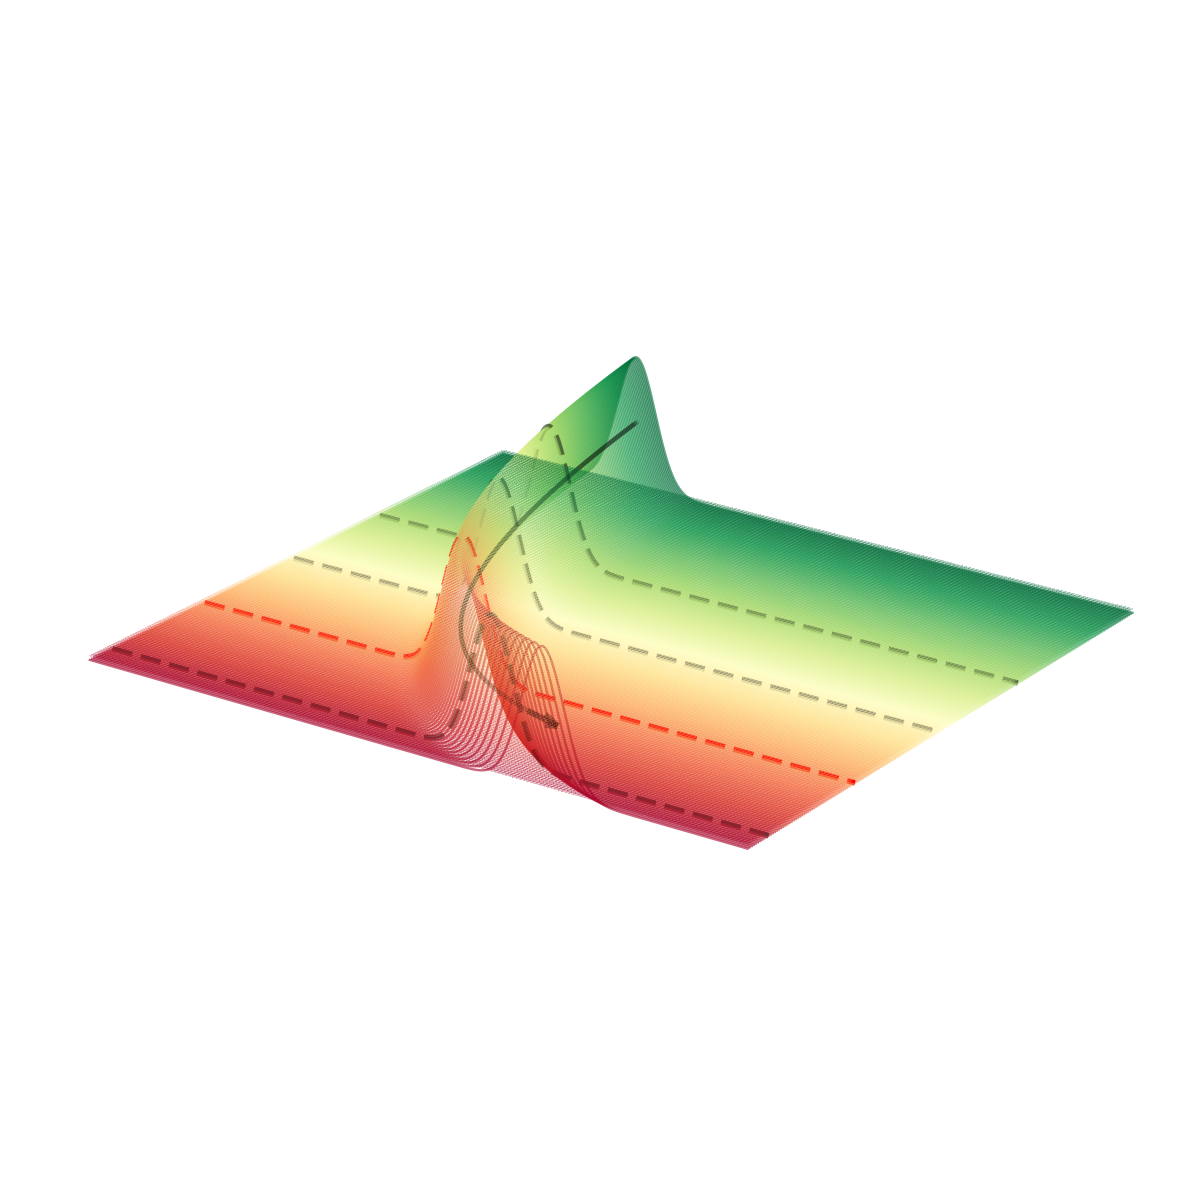

In [2]:

# --- Parameters ---
num_bumps = 200

# Cuboid dimensions
length = 1.8 * np.pi
width = 1
height = 5

# Color map
cmap = plt.get_cmap('RdYlGn')
colors = cmap(np.linspace(0, 1, num_bumps))
# Axis mapping:
# x -> length, y -> height, z -> width
vertices = np.array(
    [
        [0, 0, 0],
        [length, 0, 0],
        [length, 0, width],
        [0, 0, width],
        [0, height, 0],
        [length, height, 0],
        [length, height, width],
        [0, height, width],
    ]
)

# Draw cuboid as edges only (no face fill )
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7),
]
segments = [[vertices[i], vertices[j]] for i, j in edges]

fig = plt.figure(figsize=(6, 10))
ax = fig.add_subplot(111, projection="3d", proj_type="persp")
#ax.add_collection3d(Line3DCollection(segments, colors="black", linewidths=1.0, alpha=0.8))

# Gaussian family inside cuboid:
# loop = np.linspace(0,1,100)
# for each x0 in loop: y = 10*x0, center at x0, shared width=0.25
# All bumps have identical shape and peak height 1.
loop = np.linspace(length * 0.2, length * 0.8, num_bumps)
# Use full cuboid x-domain so each Gaussian profile is fully visible.

x_curve = np.linspace(-length/2, length/2, 480)
y_curve = np.linspace(0, height*0.9, num_bumps)
sigma = 0.25

# Stack individual Gaussian bumps (no surface rendering).
# Sample more densely where centers are near 0.75*pi.
y_dense = np.linspace(0, height*0.95, 5000)
center_dense = theta_hat_func(y_dense / height)

target_center = 0.75 * np.pi
focus_width = 0.22
focus_gain = 16
weights = 1.0 + focus_gain * np.exp(-((center_dense - target_center) / focus_width) ** 2)

cdf = np.cumsum(weights)
cdf = (cdf - cdf[0]) / (cdf[-1] - cdf[0] + 1e-12)
u = np.linspace(0, 1, num_bumps)
y_levels = np.interp(u, cdf, y_dense)
distance_to_bound = y_levels / height
z_values = 1.0 - distance_to_bound  # right-bound case: x = |d - z| with d = 1
centers = theta_hat_func(distance_to_bound)

# Add a colored base plane under the curves, colored by distance to bound.
x_plane = np.linspace(x_curve.min(), x_curve.max(), 180)
X_plane, Y_plane = np.meshgrid(x_plane, y_levels)
Z_plane = np.full_like(X_plane, 0.03)
row_color_values = np.linspace(0, 1, len(y_levels))
plane_colors = plt.cm.RdYlGn_r(np.repeat(row_color_values[:, None], x_plane.size, axis=1))
plane_colors[..., 3] = 0.22
ax.plot_surface(
    X_plane,
    Y_plane,
    Z_plane,
    facecolors=plane_colors,
    rstride=1,
    cstride=1,
    shade=False,
    linewidth=0,
    antialiased=False,
)

# Highlight bumps whose centers correspond to selected decision-variable z values.
highlight_zs = np.array([0.7, 0.5, 0.3, 0.1])
primary_highlight_z = 0.3
highlight_distances = np.abs(1.0 - highlight_zs)
highlight_indices = [int(np.argmin(np.abs(distance_to_bound - x))) for x in highlight_distances]
highlight_index_set = np.sort(list(set(highlight_indices)))
primary_highlight_index = int(np.argmin(np.abs(z_values - primary_highlight_z)))

for i, (x0, y0) in enumerate(zip(centers, y_levels)):
    z_curve = np.exp(-((x_curve - x0) / sigma) ** 2)
    c = plt.cm.RdYlGn_r(i / (num_bumps - 1 if num_bumps > 1 else 1))
    ax.plot(
        x_curve,
        np.full_like(x_curve, y0),
        z_curve,
        color=c,
        alpha=0.6,
        linewidth=0.85,
    )

    if i in highlight_index_set:
        if i != primary_highlight_index:
            color = 'black'
            alpha = 0.5
        else:
            color = 'red'
            alpha = 1
        ax.plot(
                x_curve,
                np.full_like(x_curve, y0),
                z_curve,
                color=color,
                linestyle="--",
                alpha=alpha,
                linewidth=2.0,
            )
        

# Projection of centerline on x-y plane (z=0)
# Color each segment to match the bump directly above it.
X_proj = centers
Y_proj = y_levels
for i in range(len(X_proj) - 1):
    #c = plt.cm.RdYlGn_r(i / (num_bumps - 1 if num_bumps > 1 else 1))
    c = 'black'
    ax.plot(
        X_proj[i:i+2],
        Y_proj[i:i+2],
        zs=0.5,
        zdir='z',
        color=c,
        alpha=0.2,
        linewidth=1.6,
    )

# Add an arrow at the terminal of the distance-to-bound projection path.
end_idx = np.argmax(distance_to_bound)
x_end = X_proj[end_idx]
y_end = Y_proj[end_idx]
z_end = 0.5  # projection采用的是z=0.5

# 计算箭头指向的方向，这里我们用最后一段的方向
if end_idx > 0:
    dx = X_proj[end_idx] - X_proj[end_idx - 1]
    dy = Y_proj[end_idx] - Y_proj[end_idx - 1]
    dz = 0
    norm = np.sqrt(dx**2 + dy**2)
    if norm == 0:
        dx, dy = 0.05, 0.   # fallback, unlikely
    else:
        dx /= norm
        dy /= norm
else:
    dx, dy = 0.1, 0.
dz = 0.

arrow_length = 0.33   # 可微调
ax.quiver(
    x_end - dx*arrow_length*0.5,   # 箭头尾部坐标（使箭头居中在终点一带）
    y_end - dy*arrow_length*0.5,
    z_end,
    dx,
    dy,
    dz,
    length=arrow_length,
    color="black",
    arrow_length_ratio=0.43,
    linewidth=2.2,
    lw=2.2,
    alpha=0.5,
    normalize=True
)

# Limits/aspect in mapped axes: (length, height, width)
ax.set_xlim(-3, 3)
ax.set_ylim(height, 0)
ax.set_zlim(0, width)
ax.set_box_aspect((length, height, width))

# Natural perspective view
ax.view_init(elev=22, azim=-55)

# Remove all axis decorations, ticks, grids, and frame
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off()
fig.savefig(FIGURE1_DIR / 'bump_3D_geometry.png', dpi=300)

plt.tight_layout()
plt.show()

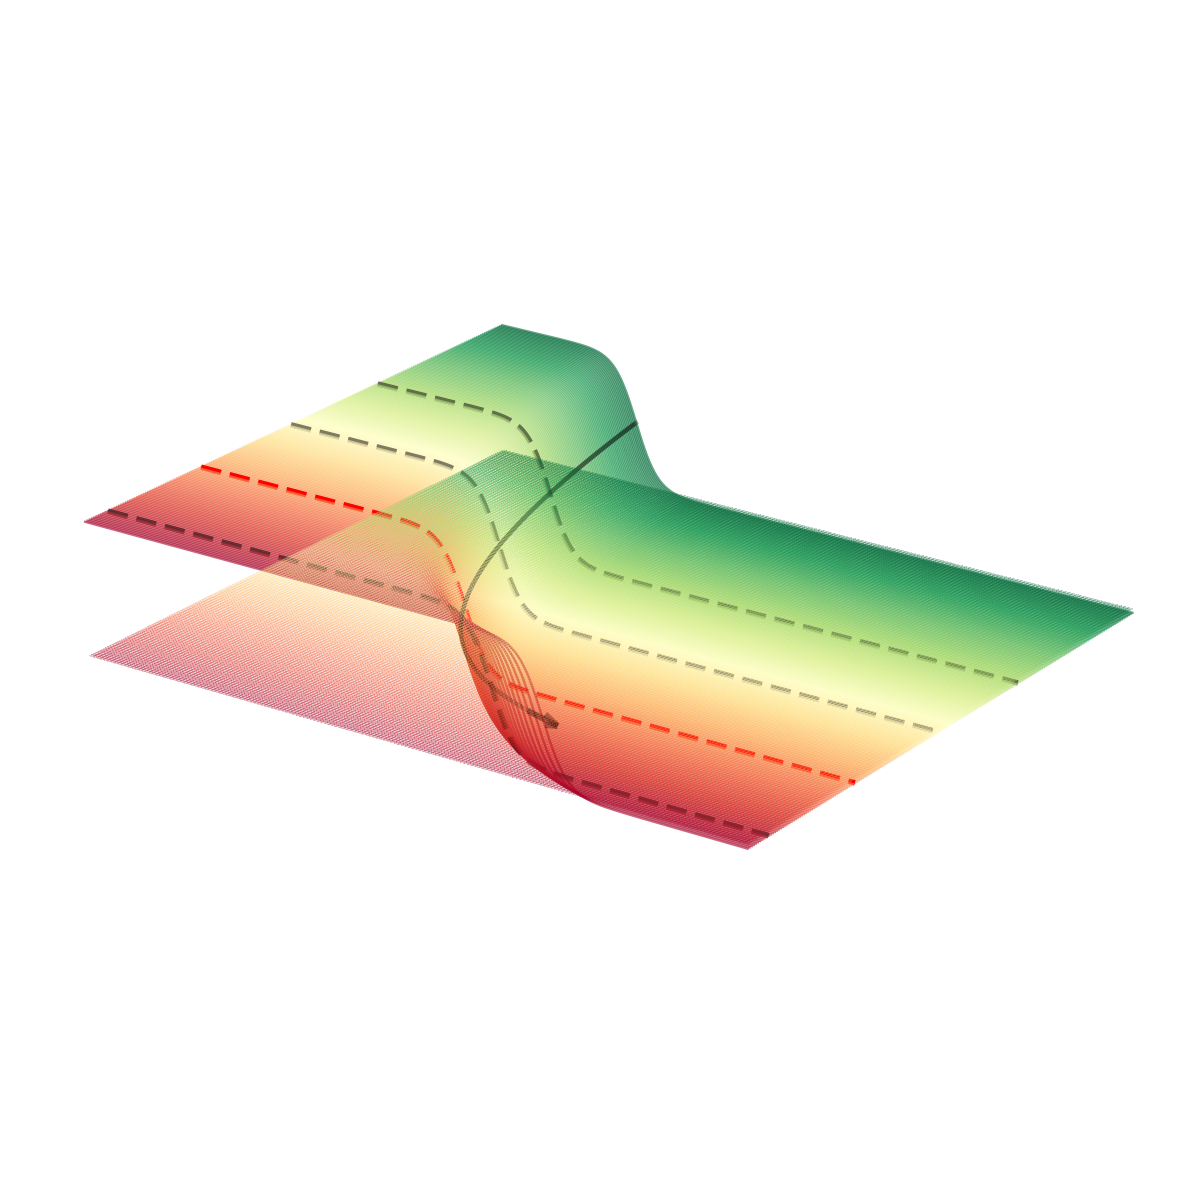

In [3]:


# --- Parameters ---
num_bumps = 200

# Cuboid dimensions
length = 1.8 * np.pi
width = 1
height = 5

# Color map
cmap = plt.get_cmap('RdYlGn')
colors = cmap(np.linspace(0, 1, num_bumps))
# Axis mapping:
# x -> length, y -> height, z -> width
vertices = np.array(
    [
        [0, 0, 0],
        [length, 0, 0],
        [length, 0, width],
        [0, 0, width],
        [0, height, 0],
        [length, height, 0],
        [length, height, width],
        [0, height, width],
    ]
)

# Draw cuboid as edges only (no face fill)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7),
]
segments = [[vertices[i], vertices[j]] for i, j in edges]

fig = plt.figure(figsize=(6, 10))
ax = fig.add_subplot(111, projection="3d", proj_type="persp")
#ax.add_collection3d(Line3DCollection(segments, colors="black", linewidths=1.0, alpha=0.8))

# Edge family inside cuboid:
# keep layout same as bump panel, only the profile shape is different.
loop = np.linspace(length * 0.2, length * 0.8, num_bumps)

x_curve = np.linspace(-length/2, length/2, 480)
y_curve = np.linspace(0, height*0.9, num_bumps)
sigma = 0.25

y_dense = np.linspace(0, height*0.95, 5000)
center_dense = theta_hat_func(y_dense / height)

target_center = 0.75 * np.pi
focus_width = 0.22
focus_gain = 16
weights = 1.0 + focus_gain * np.exp(-((center_dense - target_center) / focus_width) ** 2)

cdf = np.cumsum(weights)
cdf = (cdf - cdf[0]) / (cdf[-1] - cdf[0] + 1e-12)
u = np.linspace(0, 1, num_bumps)
y_levels = np.interp(u, cdf, y_dense)
distance_to_bound = y_levels / height
z_values = 1.0 - distance_to_bound  # right-bound case: x = |d - z| with d = 1
centers = theta_hat_func(distance_to_bound)

# Add a colored base plane under the edge curves, colored by distance to bound.
x_plane = np.linspace(x_curve.min(), x_curve.max(), 180)
X_plane, Y_plane = np.meshgrid(x_plane, y_levels)
Z_plane = np.full_like(X_plane, 0.03)
row_color_values = np.linspace(0, 1, len(y_levels))
plane_colors = plt.cm.RdYlGn_r(np.repeat(row_color_values[:, None], x_plane.size, axis=1))
plane_colors[..., 3] = 0.22
ax.plot_surface(
    X_plane,
    Y_plane,
    Z_plane,
    facecolors=plane_colors,
    rstride=1,
    cstride=1,
    shade=False,
    linewidth=0,
    antialiased=False,
)

# Highlight edge states whose centers correspond to selected decision-variable z values.
highlight_zs = np.array([0.7, 0.5, 0.3, 0.1])
primary_highlight_z = 0.3
highlight_distances = np.abs(1.0 - highlight_zs)
highlight_indices = [int(np.argmin(np.abs(distance_to_bound - x))) for x in highlight_distances]
highlight_index_set = np.sort(list(set(highlight_indices)))
primary_highlight_index = int(np.argmin(np.abs(z_values - primary_highlight_z)))

for i, (x0, y0) in enumerate(zip(centers, y_levels)):
    z_curve = sigmoid(-10*(x_curve - x0))

    c = plt.cm.RdYlGn_r(i / (num_bumps - 1 if num_bumps > 1 else 1))
    ax.plot(
        x_curve,
        np.full_like(x_curve, y0),
        z_curve,
        color=c,
        alpha=0.6,
        linewidth=0.85,
    )

    if i in highlight_index_set:
        if i != primary_highlight_index:
            color = 'black'
            alpha = 0.5
        else:
            color = 'red'
            alpha = 1
        ax.plot(
            x_curve,
            np.full_like(x_curve, y0),
            z_curve,
            color=color,
            linestyle="--",
            alpha=alpha,
            linewidth=2.0,
        )

# Projection of centerline on x-y plane
X_proj = centers
Y_proj = y_levels
for i in range(len(X_proj) - 1):
    #c = plt.cm.RdYlGn_r(i / (num_bumps - 1 if num_bumps > 1 else 1))
    c = 'black'
    ax.plot(
        X_proj[i:i+2],
        Y_proj[i:i+2],
        zs=0.5,
        zdir='z',
        color=c,
        alpha=0.2,
        linewidth=1.6,
    )

# Add an arrow at the terminal of the distance-to-bound projection path.
end_idx = np.argmax(distance_to_bound)
x_end = X_proj[end_idx]
y_end = Y_proj[end_idx]
z_end = 0.5

if end_idx > 0:
    dx = X_proj[end_idx] - X_proj[end_idx - 1]
    dy = Y_proj[end_idx] - Y_proj[end_idx - 1]
    dz = 0
    norm = np.sqrt(dx**2 + dy**2)
    if norm == 0:
        dx, dy = 0.05, 0.
    else:
        dx /= norm
        dy /= norm
else:
    dx, dy = 0.1, 0.
dz = 0.

arrow_length = 0.33
ax.quiver(
    x_end - dx*arrow_length*0.5,
    y_end - dy*arrow_length*0.5,
    z_end,
    dx,
    dy,
    dz,
    length=arrow_length,
    color="black",
    arrow_length_ratio=0.43,
    linewidth=2.2,
    lw=2.2,
    alpha=0.5,
    normalize=True
)

# Limits/aspect in mapped axes: (length, height, width)
ax.set_xlim(-3, 3)
ax.set_ylim(height, 0)
ax.set_zlim(0, width)
ax.set_box_aspect((length, height, width))

# Natural perspective view
ax.view_init(elev=22, azim=-55)

# Remove all axis decorations, ticks, grids, and frame
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off()
fig.savefig(FIGURE1_DIR / 'edge_3D_geometry.png', dpi=300)
plt.tight_layout()
plt.show()


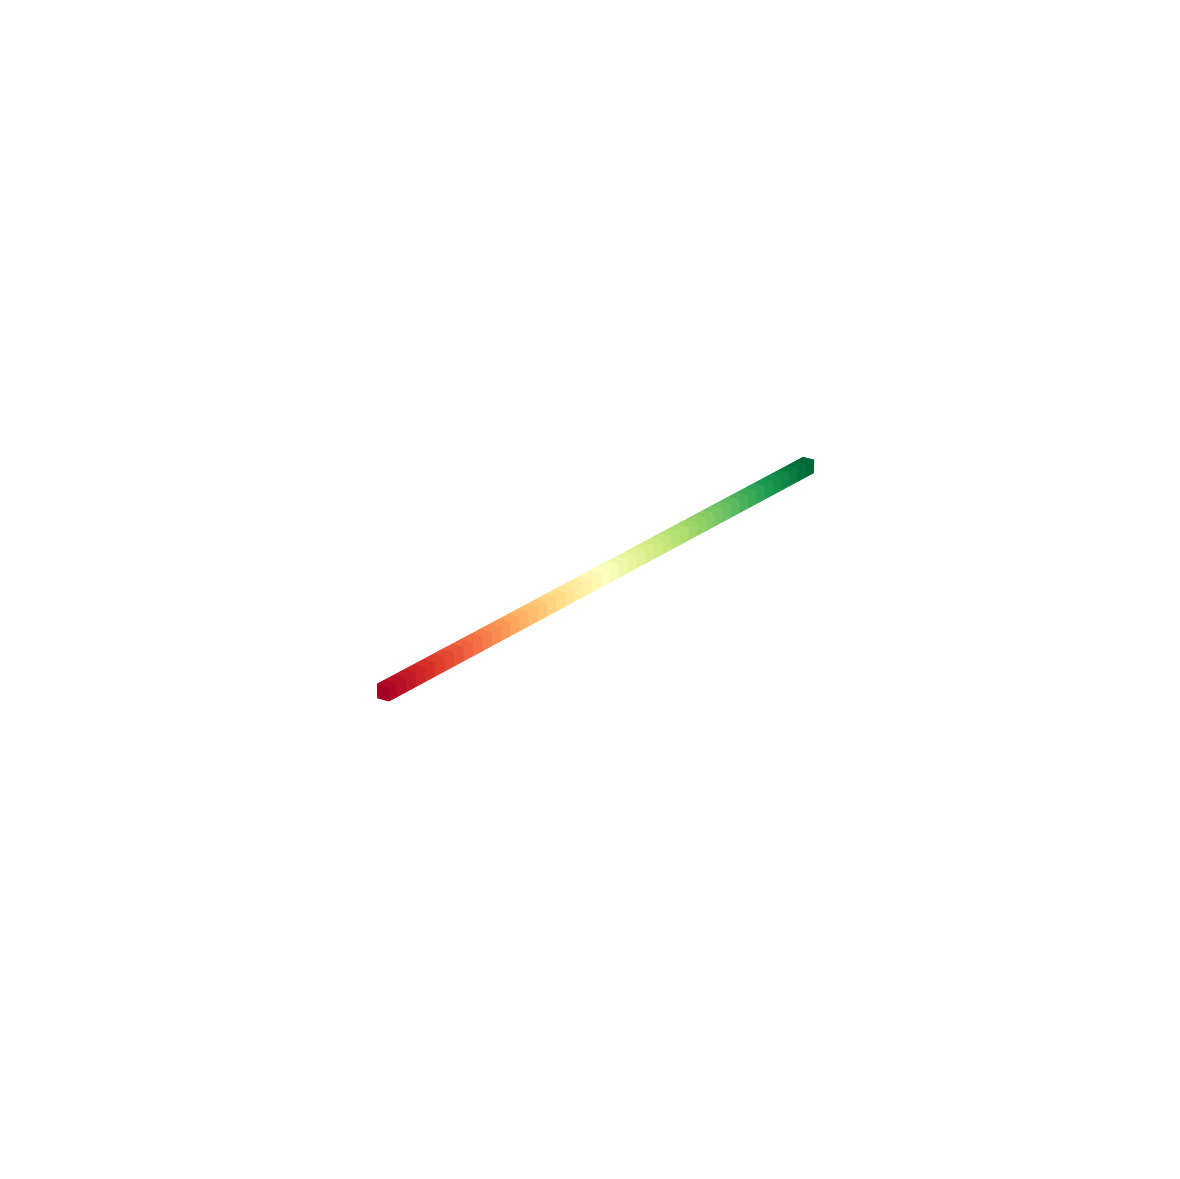

In [4]:
# Solid stick: a slim cuboid from y=0 to y=height
fig = plt.figure(figsize=(6, 10))
ax = fig.add_subplot(111, projection="3d", proj_type="persp")

# Keep colormap and perspective consistent with the original figure.
cmap = plt.get_cmap('RdYlGn_r')

stick_size = 0.1
half = stick_size / 2
x_center = 0.0
z_center = 0.5

# Stick bounds in mapped axes (x, y, z)
x0, x1 = x_center - half, x_center + half
y0, y1 = 0.0, height
z0, z1 = z_center - half, z_center + half

# Y-dependent colors so the stick follows the same gradient logic.
y_line = np.linspace(y0, y1, 240)
y_norm = (y_line - y0) / (y1 - y0 + 1e-12)
face_cols = cmap(y_norm)

# Faces parallel to x-y (z fixed)
X_xy, Y_xy = np.meshgrid(np.linspace(x0, x1, 2), y_line)
Z_xy_low = np.full_like(X_xy, z0)
Z_xy_high = np.full_like(X_xy, z1)
ax.plot_surface(X_xy, Y_xy, Z_xy_low, facecolors=face_cols[:, None, :], shade=False, linewidth=0)
ax.plot_surface(X_xy, Y_xy, Z_xy_high, facecolors=face_cols[:, None, :], shade=False, linewidth=0)

# Faces parallel to y-z (x fixed)
Y_yz, Z_yz = np.meshgrid(y_line, np.linspace(z0, z1, 2), indexing='ij')
X_yz_low = np.full_like(Y_yz, x0)
X_yz_high = np.full_like(Y_yz, x1)
ax.plot_surface(X_yz_low, Y_yz, Z_yz, facecolors=face_cols[:, None, :], shade=False, linewidth=0)
ax.plot_surface(X_yz_high, Y_yz, Z_yz, facecolors=face_cols[:, None, :], shade=False, linewidth=0)

# Top and bottom caps for a solid appearance.
X_cap, Z_cap = np.meshgrid(np.linspace(x0, x1, 2), np.linspace(z0, z1, 2))
Y_cap_bottom = np.full_like(X_cap, y0)
Y_cap_top = np.full_like(X_cap, y1)
ax.plot_surface(X_cap, Y_cap_bottom, Z_cap, color=cmap(0.0), shade=False, linewidth=0)
ax.plot_surface(X_cap, Y_cap_top, Z_cap, color=cmap(1.0), shade=False, linewidth=0)

# Match geometry/layout of original panel
ax.set_xlim(-3, 3)
ax.set_ylim(height, 0)
ax.set_zlim(0, width)
ax.set_box_aspect((length, height, width))
ax.view_init(elev=22, azim=-55)

# Remove axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.show()